# 

# Univariate Distribution Plots

## Figure 1 - Univariate Distributions & Default Rate by Bin

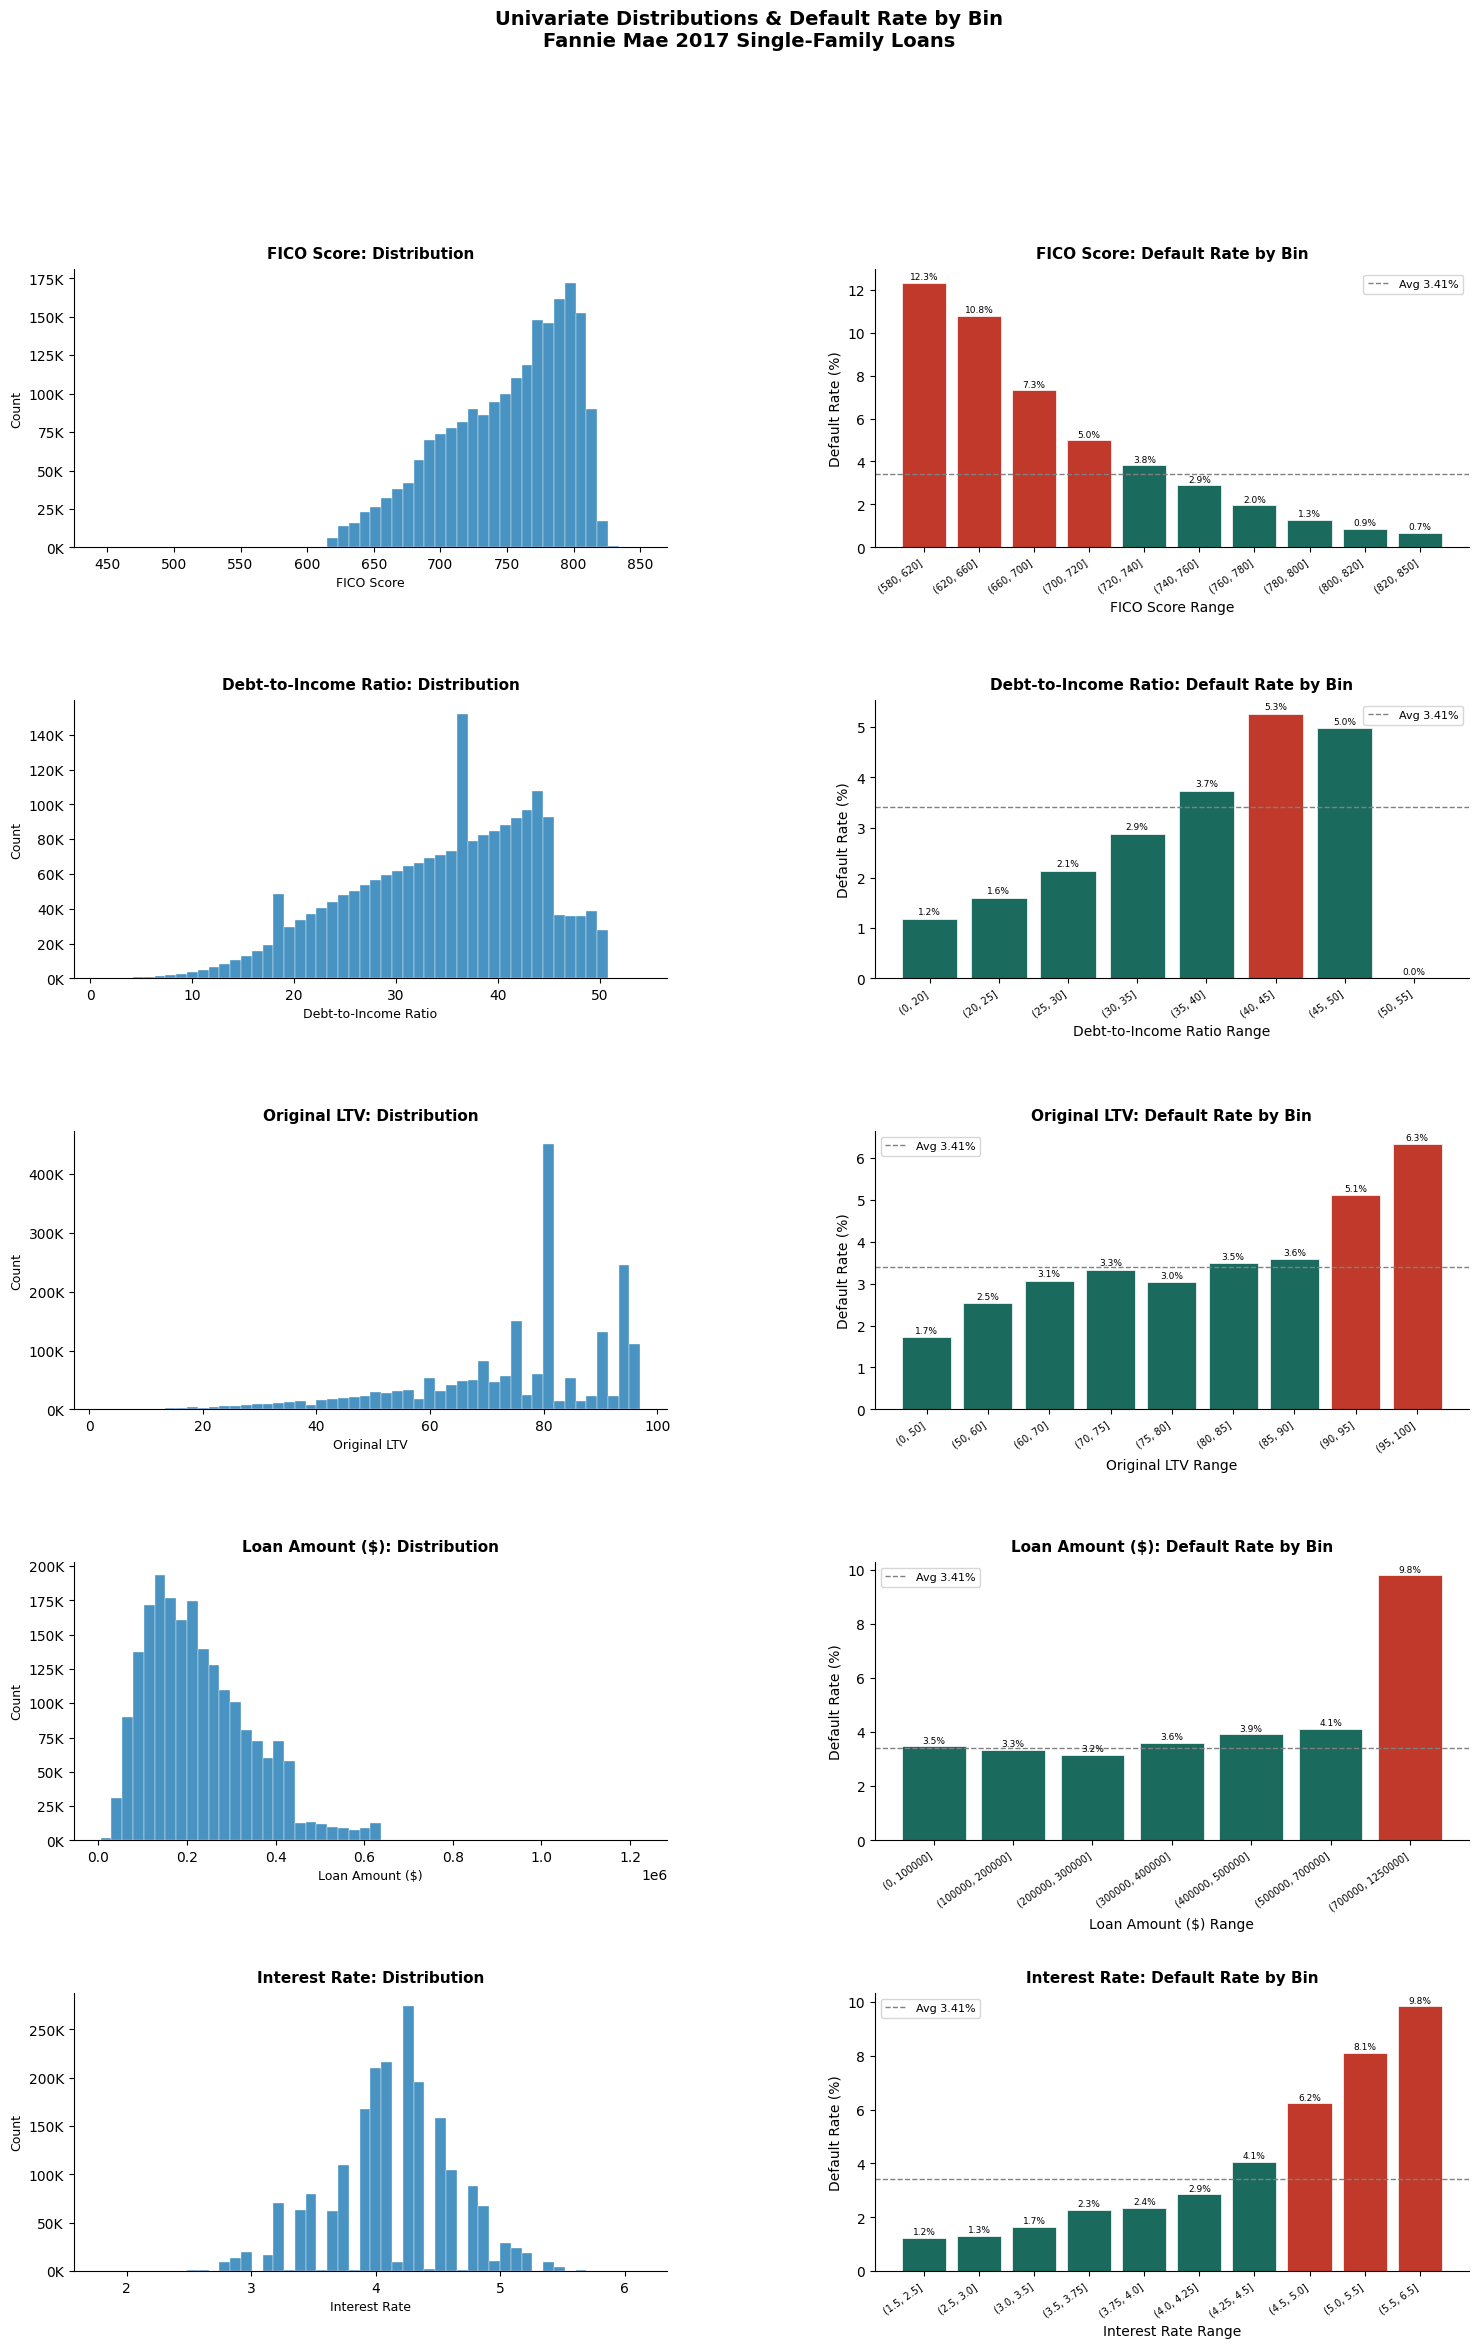

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_parquet("../data/processed/fannie_2017_clean.parquet")

# coerce key columns to numeric
for c in ['OLTV', 'OCLTV', 'DTI', 'CSCORE_B']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df['default_flag'] = df['default_flag'].astype(float)


BAR_COLOR  = '#1a6b5e'
HIGH_COLOR = '#c0392b'  
LOW_COLOR  = '#2ecc71'
HIST_COLOR = '#2980b9'

fig = plt.figure(figsize=(18, 26))
gs = gridspec.GridSpec(5, 2, figure=fig, hspace=0.55, wspace=0.35)

features = [
    ('CSCORE_B', 'FICO Score',[580, 620, 660, 700, 720, 740, 760, 780, 800, 820, 850]),
    ('DTI',      'Debt-to-Income Ratio', [0, 20, 25, 30, 35, 40, 45, 50, 55]),
    ('OLTV',     'Original LTV', [0, 50, 60, 70, 75, 80, 85, 90, 95, 100]),
    ('ORIG_UPB', 'Loan Amount ($)', [0, 100000, 200000, 300000, 400000, 500000, 700000, 1250000]),
    ('ORIG_RATE', 'Interest Rate', [1.5, 2.5, 3.0, 3.5, 3.75, 4.0, 4.25, 4.5, 5.0, 5.5, 6.5])
]

for i, (col, label, bins) in enumerate(features):
    row = i

    # left: histogram of raw distribution 
    ax1 = fig.add_subplot(gs[row, 0])
    ax1.hist(df[col].dropna(), bins=50, color=HIST_COLOR, alpha=0.85,
             edgecolor='white', linewidth=0.3)
    ax1.set_title(f'{label}: Distribution', fontsize=11, fontweight='bold', pad=8)
    ax1.set_xlabel(label, fontsize=9)
    ax1.set_ylabel('Count', fontsize=9)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}K'))
    ax1.set_facecolor('white')
    ax1.spines[['top', 'right']].set_visible(False)

    # right: default rate by bin 
    ax2 = fig.add_subplot(gs[row, 1])
    df['_bin'] = pd.cut(df[col], bins=bins)
    bin_stats = df.groupby('_bin', observed=True)['default_flag'].mean().reset_index()
    bin_stats['label'] = bin_stats['_bin'].astype(str)

    colors = [HIGH_COLOR if v > 0.05 else BAR_COLOR for v in bin_stats['default_flag']]
    bars = ax2.bar(range(len(bin_stats)), bin_stats['default_flag'] * 100,
                   color=colors, edgecolor='white', linewidth=0.5)

    # portfolio average reference line
    ax2.axhline(y=3.41, color='gray', linestyle='--', linewidth=1, label='Avg 3.41%')
    ax2.set_title(f'{label}: Default Rate by Bin', fontsize=11, fontweight='bold', pad=8)
    ax2.set_xlabel(label + ' Range')
    ax2.set_ylabel('Default Rate (%)')
    ax2.set_xticks(range(len(bin_stats)))
    ax2.set_xticklabels(bin_stats['label'], rotation=35, ha='right', fontsize=7)
    ax2.legend(fontsize=8)
    ax2.set_facecolor('white')
    ax2.spines[['top', 'right']].set_visible(False)

    for bar, val in zip(bars, bin_stats['default_flag']):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontsize=6.5)

fig.suptitle(
    'Univariate Distributions & Default Rate by Bin\nFannie Mae 2017 Single-Family Loans',
    fontsize=14, fontweight='bold', y=0.98
)

plt.show()

**Observations (Figure 1):**
- FICO is the clearest risk signal
    - borrowers below 660 default at 10-12%, while those above 760 drop below 2%. Sharp cliff around 700
- DTI shows a steady climb 
    - default stays flat below 35 then accelerates above 40, hitting 5%+ above 45
- LTV risk is concentrated at the high end 
    - loans above 95 LTV default at 6.3%, nearly 2× the average
- Loan Amount is mostly flat until jumbo-sized loans ($700K+) spike to 9.8%
    - likely reflects geographic concentration in expensive markets
- Interest Rate is strongly monotonic 
    - higher rate loans default more, rising from 1.2% at low rates to 9.8% at the top band, reflecting how lenders price risk

## Figure 2 — Borrower Demographics

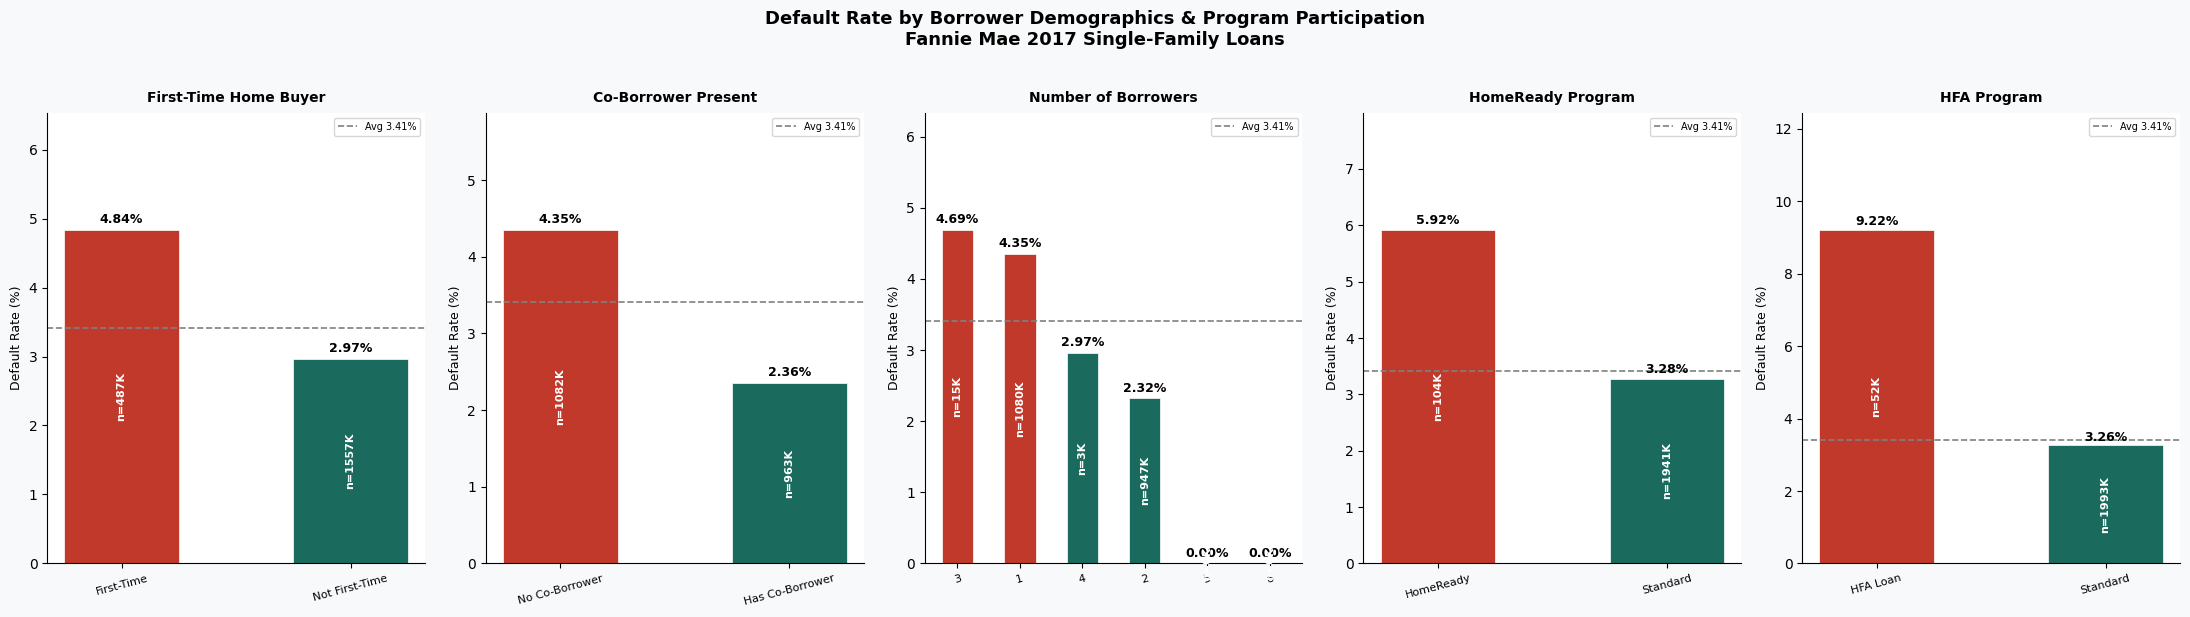

In [3]:
df['NUM_BO'] = df['NUM_BO'].astype(str)


BAR_COLOR  = '#1a6b5e'
HIGH_COLOR = '#c0392b'
AVG_RATE   = 3.41

features = [
    ('is_first_time',  'First-Time Home Buyer',  {0: 'Not First-Time', 1: 'First-Time'}),
    ('has_coborrower', 'Co-Borrower Present',     {0: 'No Co-Borrower', 1: 'Has Co-Borrower'}),
    ('NUM_BO',         'Number of Borrowers',     {'1': '1', '2': '2', '3': '3', '4': '4'}),
    ('is_homeready',   'HomeReady Program',       {0: 'Standard', 1: 'HomeReady'}),
    ('is_hfa',         'HFA Program',             {0: 'Standard', 1: 'HFA Loan'}),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.patch.set_facecolor('#f8f9fa')
fig.suptitle(
    'Default Rate by Borrower Demographics & Program Participation\n'
    'Fannie Mae 2017 Single-Family Loans',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, (col, label, mapping) in zip(axes, features):
    stats = df.groupby(col)['default_flag'].agg(['mean', 'count']).reset_index()
    stats['label'] = stats[col].map(mapping).fillna(stats[col].astype(str))
    stats['pct']   = stats['mean'] * 100
    stats = stats.sort_values('pct', ascending=False)

    colors = [HIGH_COLOR if v > AVG_RATE else BAR_COLOR for v in stats['pct']]
    bars = ax.bar(stats['label'], stats['pct'], color=colors,
                  edgecolor='white', linewidth=0.5, width=0.5)

    ax.axhline(y=AVG_RATE, color='gray', linestyle='--',
               linewidth=1.2, label=f'Avg {AVG_RATE}%')

    for bar, row in zip(bars, stats.itertuples()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{row.pct:.2f}%',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f'n={row.count/1000:.0f}K',
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold', rotation= 90)

    ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('Default Rate (%)', fontsize=9)
    ax.set_ylim(0, max(stats['pct']) * 1.35)
    ax.tick_params(axis='x', labelsize=8, rotation=15)
    ax.legend(fontsize=7)
    ax.set_facecolor('white')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations - Figure 2**
- First-time buyers (4.84%) default at 63% above the average
    - less financial cushion and experience
- Solo borrowers (no co-borrower) default at 4.35% vs 2.36% with a partner
    - second income is a meaningful buffer
- HomeReady (5.92%) and HFA (9.22%) loans confirm that assistance program participation is a strong proxy for financial vulnerability

## Figure 3 - Lenders

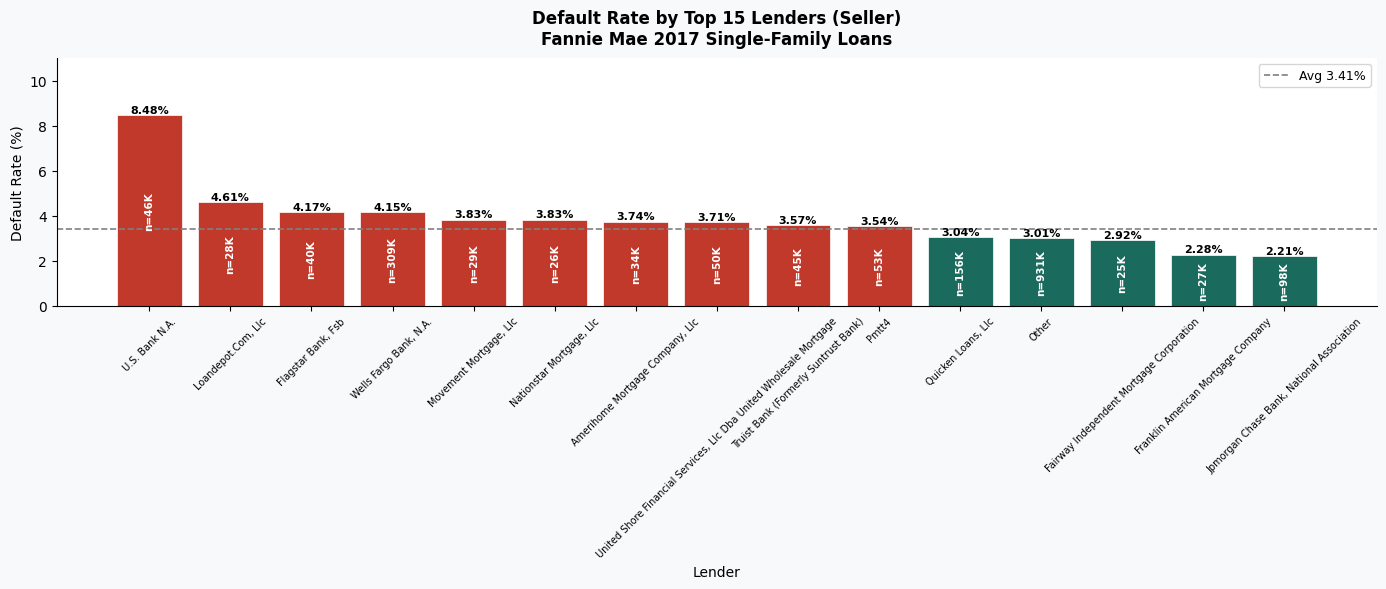

In [6]:
BAR_COLOR  = '#1a6b5e'
HIGH_COLOR = '#c0392b'
AVG_RATE   = 3.41

# two records of quicken loans
df['SELLER'] = df['SELLER'].replace('Quicken Loans Inc.', 'Quicken Loans, Llc')

top_sellers = df['SELLER'].value_counts().head(15).index
stats = (df[df['SELLER'].isin(top_sellers)]
         .groupby('SELLER')['default_flag']
         .agg(['mean', 'count'])
         .reset_index())
stats['pct'] = stats['mean'] * 100
stats = stats.sort_values('pct', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#f8f9fa')

colors = [HIGH_COLOR if v > AVG_RATE else BAR_COLOR for v in stats['pct']]
bars = ax.bar(stats['SELLER'], stats['pct'], color=colors,
              edgecolor='white', linewidth=0.5)

ax.axhline(y=AVG_RATE, color='gray', linestyle='--',
           linewidth=1.2, label=f'Avg {AVG_RATE}%')

for bar, row in zip(bars, stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{row.pct:.2f}%',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() / 2,
            f'n={row.count/1000:.0f}K',
            ha='center', va='center',
            fontsize=7.5, color='white', fontweight='bold',
            rotation=90)

ax.set_title('Default Rate by Top 15 Lenders (Seller)\nFannie Mae 2017 Single-Family Loans',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Default Rate (%)', fontsize=10)
ax.set_xlabel('Lender', fontsize=10)
ax.set_ylim(0, max(stats['pct']) * 1.3)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.legend(fontsize=9)
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations (Figure 3)**
- U.S. Bank N.A. stands out at 8.48% 
    - nearly 4x JPMorgan Chase (2.21%) despite similar borrower profiles, suggesting origination quality differences beyond what FICO and DTI capture
- Most large lenders (Wells Fargo, Quicken, JPMorgan) cluster near or below average
- "Other" at 3.01% — the 931K unknown lenders perform close to average

## Figure 4 - State Distribution

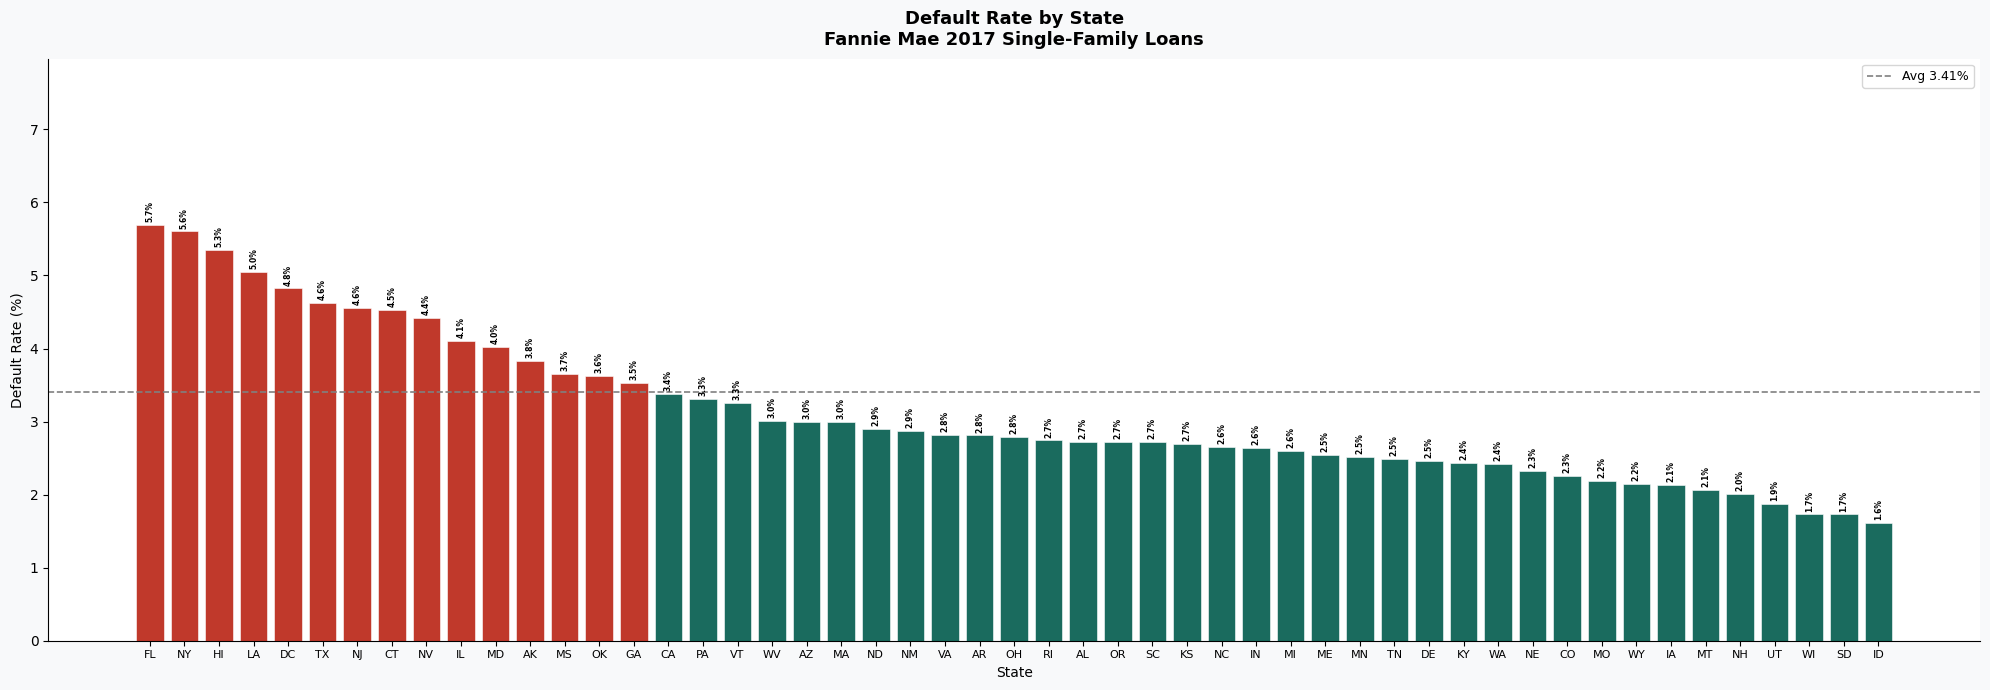

In [7]:

# drop territories small sample sizes
exclude = ['VI', 'PR', 'GU']
stats = df[~df['STATE'].isin(exclude)].groupby('STATE')['default_flag'].agg(['mean', 'count']).reset_index()
stats['pct'] = stats['mean'] * 100
stats = stats.sort_values('pct', ascending=False)

BAR_COLOR  = '#1a6b5e'
HIGH_COLOR = '#c0392b'
AVG_RATE   = 3.41

fig, ax = plt.subplots(figsize=(20, 7))
fig.patch.set_facecolor('#f8f9fa')

colors = [HIGH_COLOR if v > AVG_RATE else BAR_COLOR for v in stats['pct']]
bars = ax.bar(stats['STATE'], stats['pct'], color=colors,
              edgecolor='white', linewidth=0.4)

ax.axhline(y=AVG_RATE, color='gray', linestyle='--',
           linewidth=1.2, label=f'Avg {AVG_RATE}%')

# annotate bars with default rate
for bar, row in zip(bars, stats.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.04,
            f'{row.pct:.1f}%',
            ha='center', va='bottom', fontsize=5.5,
            fontweight='bold', rotation=90)

ax.set_title('Default Rate by State\nFannie Mae 2017 Single-Family Loans',
             fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Default Rate (%)', fontsize=10)
ax.set_xlabel('State', fontsize=10)
ax.set_ylim(0, max(stats['pct']) * 1.4)
ax.tick_params(axis='x', labelsize=8)
ax.legend(fontsize=9)
ax.set_facecolor('white')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observations (Figure 4)**

- Florida (5.7%) and New York (5.6%) are the highest risk states with large loan volumes 
    - Significant concentration risk
- Midwest and Mountain West states (ID, SD, WI, UT) are consistently the safest under 2%
- Coastal and southern states dominate the high-risk end, directly informing the LP diversification constraints